In [1]:
import yfinance as yf
import pandas as pd

In [2]:
eth = yf.download("ETH-USD", start="2018-01-01")
eth.columns = eth.columns.droplevel(1)

[*********************100%***********************]  1 of 1 completed


In [3]:
print(eth.head())

Price            Close         High         Low        Open      Volume
Date                                                                   
2018-01-01  772.640991   782.530029  742.004028  755.757019  2595760128
2018-01-02  884.443970   914.830017  772.346008  772.346008  5783349760
2018-01-03  962.719971   974.471008  868.450989  886.000000  5093159936
2018-01-04  980.921997  1045.079956  946.085999  961.713013  6502859776
2018-01-05  997.719971  1075.390015  956.325012  975.750000  6683149824


In [4]:
eth.to_csv("eth_data.csv")

In [5]:
eth = pd.read_csv("eth_data.csv")

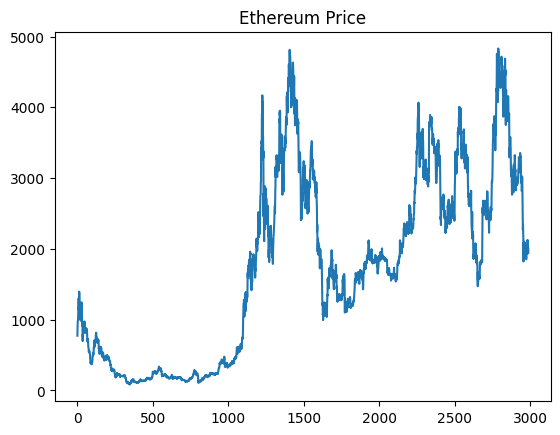

In [6]:
import matplotlib.pyplot as plt

plt.plot(eth['Close'])
plt.title("Ethereum Price")
plt.show()

In [7]:
import numpy as np

eth['returns'] = np.log(eth['Close'] / eth['Close'].shift(1))

In [8]:
eth.head()

,Date,Close,High,Low,Open,Volume,returns
0,2018-01-01,772.640991,782.530029,742.004028,755.757019,2595760128,NaN
1,2018-01-02,884.443970,914.830017,772.346008,772.346008,5783349760,0.135145
2,2018-01-03,962.719971,974.471008,868.450989,886.000000,5093159936,0.084803
3,2018-01-04,980.921997,1045.079956,946.085999,961.713013,6502859776,0.018730
4,2018-01-05,997.719971,1075.390015,956.325012,975.750000,6683149824,0.016980


In [9]:
eth['volatility'] = eth['returns'].rolling(30).std()

In [10]:
eth.head()

,Date,Close,High,Low,Open,Volume,returns,volatility
0,2018-01-01,772.640991,782.530029,742.004028,755.757019,2595760128,NaN,NaN
1,2018-01-02,884.443970,914.830017,772.346008,772.346008,5783349760,0.135145,NaN
2,2018-01-03,962.719971,974.471008,868.450989,886.000000,5093159936,0.084803,NaN
3,2018-01-04,980.921997,1045.079956,946.085999,961.713013,6502859776,0.018730,NaN
4,2018-01-05,997.719971,1075.390015,956.325012,975.750000,6683149824,0.016980,NaN


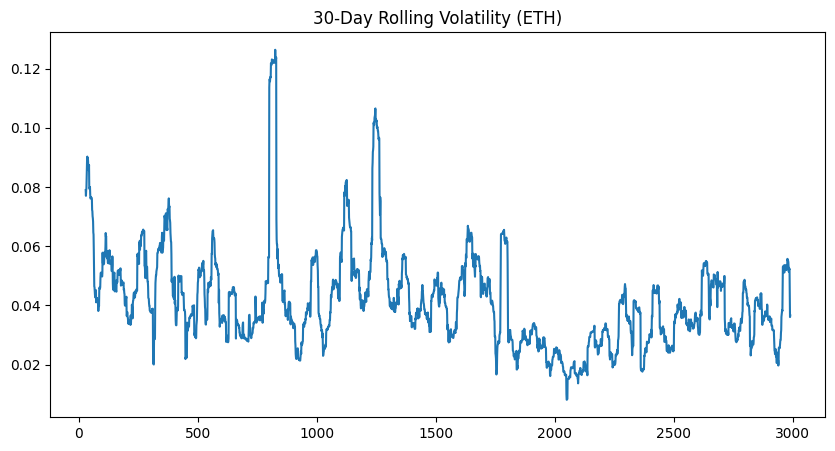

In [11]:
plt.figure(figsize=(10,5))
plt.plot(eth['volatility'])
plt.title("30-Day Rolling Volatility (ETH)")
plt.show()

In [12]:
eth['Vol_Lag1'] = eth['volatility'].shift(1)
eth['Vol_Lag5'] = eth['volatility'].shift(5)
eth['Vol_Lag10'] = eth['volatility'].shift(10)

In [13]:
eth['MA_20'] = eth['Close'].rolling(20).mean()
eth['MA_50'] = eth['Close'].rolling(50).mean()

In [14]:
delta = eth['Close'].diff()

gain = (delta.where(delta > 0, 0)).rolling(14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(14).mean()

rs = gain / loss
eth['RSI'] = 100 - (100 / (1 + rs))

In [15]:
eth['Volume_MA'] = eth['Volume'].rolling(20).mean()

In [16]:
eth = eth.dropna()

In [17]:
X = eth[['MA_20','MA_50','RSI','Volume_MA','Vol_Lag1',
    'Vol_Lag5',
    'Vol_Lag10'
]]

In [18]:
y = eth['volatility']

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

In [20]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [21]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [22]:
from xgboost import XGBRegressor

xgb = XGBRegressor()
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

In [23]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

print("Linear Regression RMSE:", rmse_lr)
print("Random Forest RMSE:", rmse_rf)
print("XGBoost RMSE:", rmse_xgb)

Linear Regression RMSE: 0.002341215801049944
Random Forest RMSE: 0.002270312001085075
XGBoost RMSE: 0.0025666727410497536


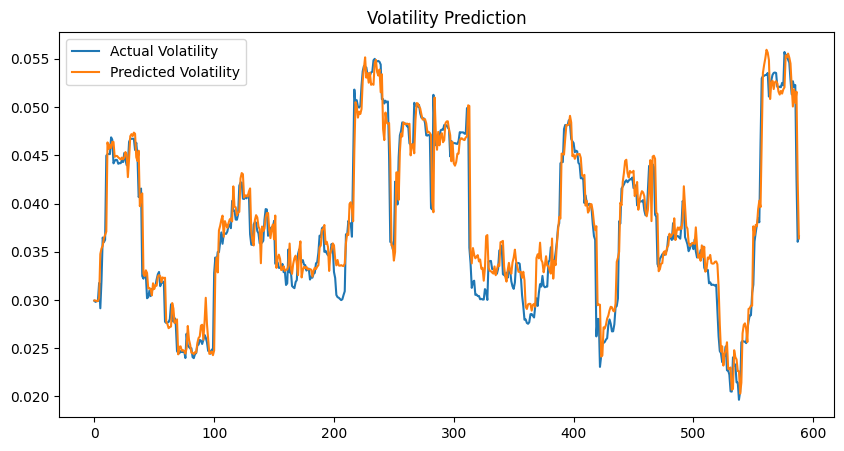

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(y_test.values, label="Actual Volatility")
plt.plot(y_pred_rf, label="Predicted Volatility")
plt.legend()
plt.title("Volatility Prediction")
plt.show()

In [25]:
import pandas as pd

importance = rf.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

print(feature_importance)

     Feature  Importance
4   Vol_Lag1    0.973143
1      MA_50    0.006165
3  Volume_MA    0.005617
0      MA_20    0.005529
5   Vol_Lag5    0.003968
2        RSI    0.003507
6  Vol_Lag10    0.002072


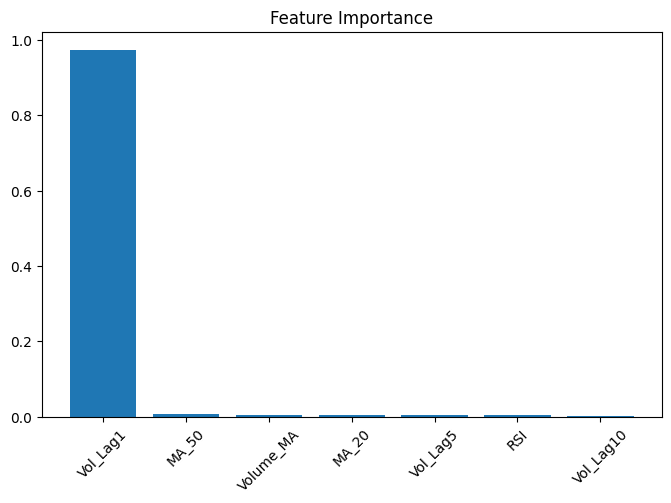

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(feature_importance["Feature"], feature_importance["Importance"])
plt.title("Feature Importance")
plt.xticks(rotation=45)
plt.show()

In [27]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

for train_index, test_index in tscv.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    rf.fit(X_train, y_train)
    preds = rf.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, preds))
    print("Fold RMSE:", rmse)

Fold RMSE: 0.011941507088244544
Fold RMSE: 0.004767649358367587
Fold RMSE: 0.0029378561572667495
Fold RMSE: 0.0023441797768819833
Fold RMSE: 0.002511883026703073


In [33]:
from arch import arch_model

model = arch_model(eth['returns']*100, vol='Garch', p=1, q=1)

garch_fit = model.fit()

forecast = garch_fit.forecast(horizon=1)

print(forecast.variance.tail())

Iteration:      1,   Func. Count:      6,   Neg. LLF: 11699.118038237328
Iteration:      2,   Func. Count:     13,   Neg. LLF: 1671650.7145598172
Iteration:      3,   Func. Count:     20,   Neg. LLF: 14346.786264922986
Iteration:      4,   Func. Count:     29,   Neg. LLF: 8601.40565847678
Iteration:      5,   Func. Count:     37,   Neg. LLF: 9759.966228007885
Iteration:      6,   Func. Count:     43,   Neg. LLF: 8373.796472876633
Iteration:      7,   Func. Count:     48,   Neg. LLF: 8373.773572032052
Iteration:      8,   Func. Count:     53,   Neg. LLF: 8373.772949332428
Iteration:      9,   Func. Count:     58,   Neg. LLF: 8373.772946662484
Iteration:     10,   Func. Count:     62,   Neg. LLF: 8373.772946663637
Optimization terminated successfully    (Exit mode 0)
            Current function value: 8373.772946662484
            Iterations: 10
            Function evaluations: 62
            Gradient evaluations: 10
            h.1
2989  17.708925


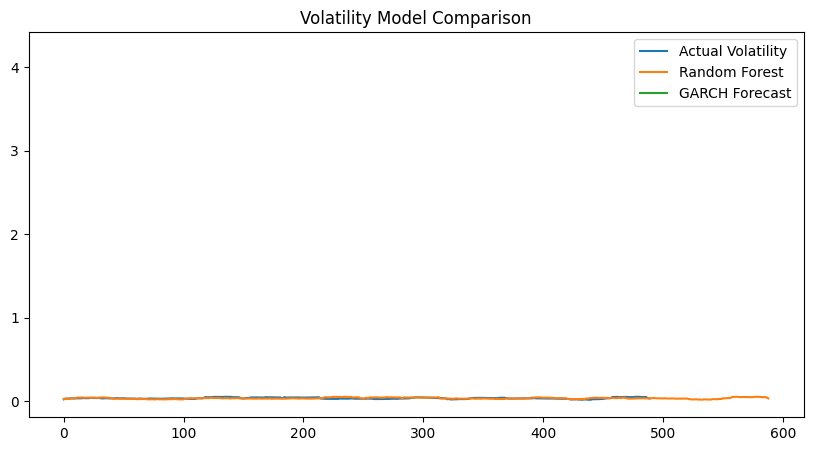

In [34]:
garch_vol = np.sqrt(forecast.variance.values[-len(y_test):])

plt.figure(figsize=(10,5))
plt.plot(y_test.values, label="Actual Volatility")
plt.plot(y_pred_rf, label="Random Forest")
plt.plot(garch_vol, label="GARCH Forecast")
plt.legend()
plt.title("Volatility Model Comparison")
plt.show()